# 1. Importing necessary libraries and dataset with engineered features

In [58]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [59]:
#Importing the Dataframe with the features

df = pd.read_csv('/Users/arthurassis/Documents/CCT - Data Analytics for Business/Machine Learning/Semester 2/CA01-MachineLearning-Semester2/CA01-MachineLearning/Python-Forecasting-Electrical-Demand-on-Spain/part_2_output_features_engineered.csv',
                parse_dates = ['timestamp'])

In [60]:
df.set_index('timestamp', inplace = True)

# 2. EDA

In [61]:
#Verifying first 5 lines of the dataset

df.head()

,total load actual,total load forecast,year,month,doy,dom,dow,woy,hour,is_leap_year,...,month_cos,doy_sin,doy_cos,woy_sin,woy_cos,season,is_weekend,is_end_of_year,is_christmas,is_holiday
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,25385.0,26118.0,2015,1,1,1,3,1,0,False,...,0.866025,0.017213,0.999852,0.120537,0.992709,Winter,False,False,False,1
2015-01-01 01:00:00,24382.0,24934.0,2015,1,1,1,3,1,1,False,...,0.866025,0.017213,0.999852,0.120537,0.992709,Winter,False,False,False,1
2015-01-01 02:00:00,22734.0,23515.0,2015,1,1,1,3,1,2,False,...,0.866025,0.017213,0.999852,0.120537,0.992709,Winter,False,False,False,1
2015-01-01 03:00:00,21286.0,22642.0,2015,1,1,1,3,1,3,False,...,0.866025,0.017213,0.999852,0.120537,0.992709,Winter,False,False,False,1
2015-01-01 04:00:00,20264.0,21785.0,2015,1,1,1,3,1,4,False,...,0.866025,0.017213,0.999852,0.120537,0.992709,Winter,False,False,False,1


In [62]:
#Printing summary of information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2015-01-01 00:00:00 to 2018-12-31 23:00:00
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   total load actual    35064 non-null  float64
 1   total load forecast  35064 non-null  float64
 2   year                 35064 non-null  int64  
 3   month                35064 non-null  int64  
 4   doy                  35064 non-null  int64  
 5   dom                  35064 non-null  int64  
 6   dow                  35064 non-null  int64  
 7   woy                  35064 non-null  int64  
 8   hour                 35064 non-null  int64  
 9   is_leap_year         35064 non-null  bool   
 10  hour_sin             35064 non-null  float64
 11  hour_cos             35064 non-null  float64
 12  dow_sin              35064 non-null  float64
 13  dow_cos              35064 non-null  float64
 14  month_sin            35064 non-null  float64
 15  m

In [63]:
print("The first timestamp of the dataset:", df.index.min())
print("The last timestamp of the dataset:", df.index.max())

The first timestamp of the dataset: 2015-01-01 00:00:00
The last timestamp of the dataset: 2018-12-31 23:00:00


How many hours are there in each year?

In [64]:
#Counting how many hours are there in each year of the dataset

df.groupby(by = 'year')['hour'].count()

year
2015    8760
2016    8784
2017    8760
2018    8760
Name: hour, dtype: int64

2016 was a leap year, therefore it had an extra day. 

In [65]:
#Printing a descriptive analysis of our target variable

df['total load actual'].describe()

count    35064.000000
mean     28698.586941
std       4575.340273
min      18041.000000
25%      24807.000000
50%      28902.000000
75%      32194.250000
max      41015.000000
Name: total load actual, dtype: float64

The Maximum load is 41,015 MW and the Minimum load is 18,041 Mw.

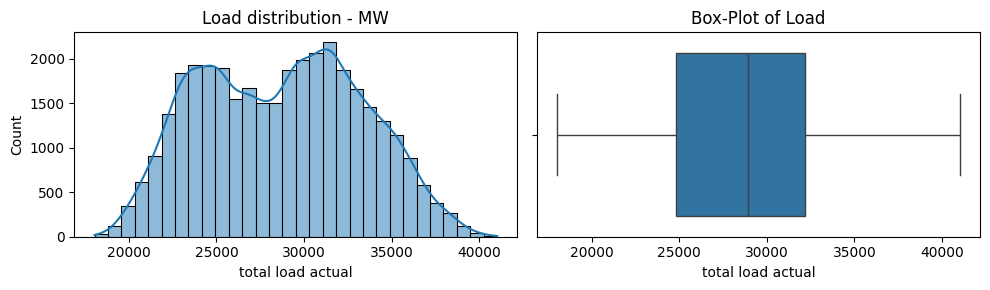

In [66]:
#Plotting a histogram of total load distribution

fig, ax = plt.subplots(1, 2,figsize=[10, 3])
sns.histplot(data=df, x='total load actual', bins=30, kde=True, ax=ax[0])
ax[0].set_title('Load distribution - MW')
sns.boxplot(data = df, x='total load actual', ax = ax[1])
ax[1].set_title('Box-Plot of Load')
fig.tight_layout()
fig.show()

This is a bimodal distribution. Therefore models that can handle this type of distribution will be mandatory. We can verify the data does not present outliers.

## 2.1 Business Value

The total energy consumed in spain by year from 2015 until 2018 is described below, in GWh.

In [68]:
#Grouping data by year

df.groupby('year')['total load actual'].sum()/1000

year
2015    248459.6535
2016    250412.8150
2017    252803.9805
2018    254610.8035
Name: total load actual, dtype: float64

In [74]:
#Create a group to plot the data

year_group = (df.groupby('year')['total load actual'].sum()/1000).reset_index()

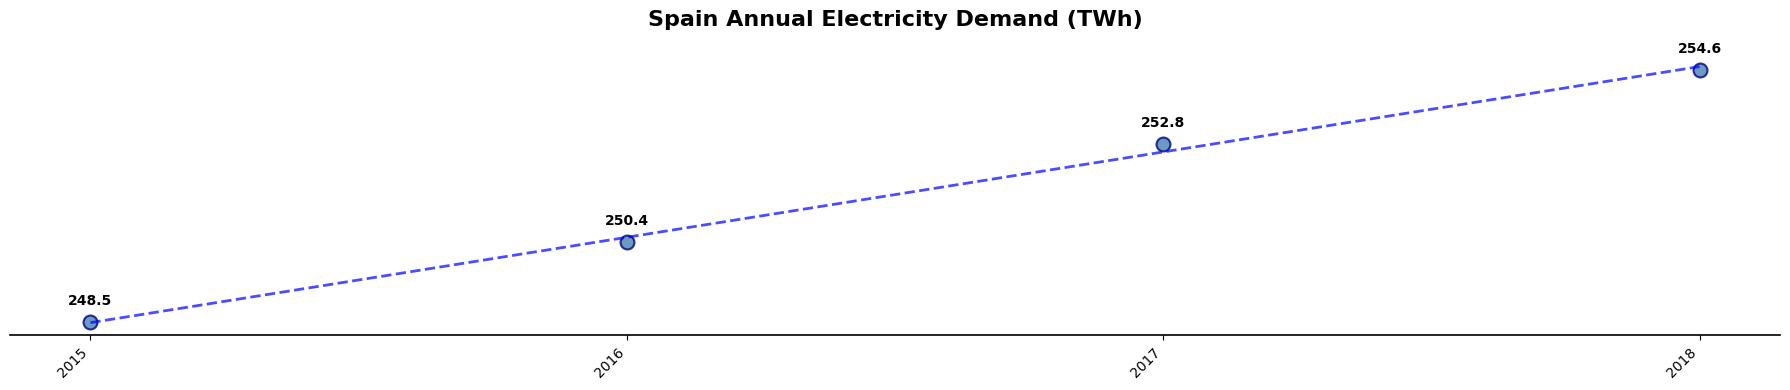

In [78]:
fig, ax = plt.subplots(figsize = (18,4))

scatter = ax.scatter(year_group['year'], year_group['total load actual']/1000, 
                     s=100, color='steelblue', alpha=0.8, edgecolors='navy', linewidth=1.5)

# Trend line (linear regression)
z = np.polyfit(year_group['year'], year_group['total load actual']/1000, 1)
p = np.poly1d(z)
ax.plot(year_group['year'], p(year_group['year']), "b--", alpha=0.7, linewidth=2)

# 2. Add y‑values above each point (in TWh)
for i, year in enumerate(year_group['year']):
    value_twh = year_group['total load actual'].iloc[i] / 1000
    ax.annotate(f'{value_twh:.1f}', 
                xy=(year, value_twh), xytext=(0, 10),
                textcoords='offset points', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

# 1. Remove y‑axis completely
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 4. Show only full years on x‑axis
ax.set_xticks(year_group['year'])  # only integer years
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# 5+6. Already divided by 1000 (TWh), nice title
ax.set_title('Spain Annual Electricity Demand (TWh)', fontsize=16, fontweight='bold', pad=20)
ax.spines['bottom'].set_linewidth(1.2)

plt.tight_layout()
plt.show()

It is possible to see a clear increasing tendency between 2015 and 2018, the consume of energy increases by approximatelly 2 TBh per year. 

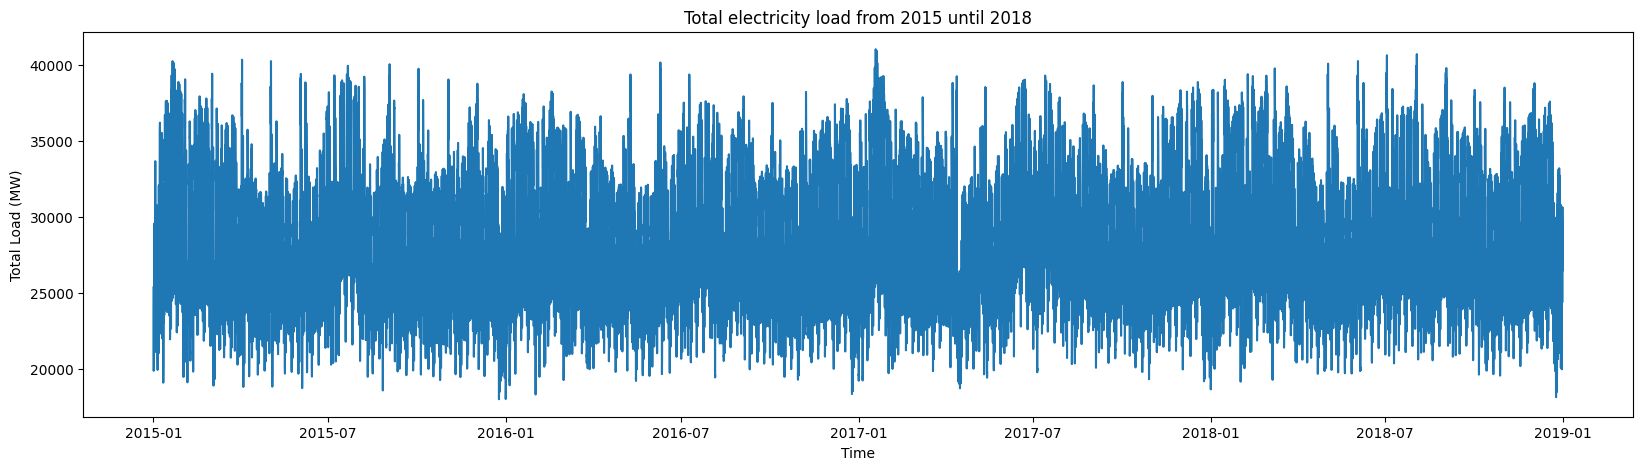

In [12]:
#Printing the timeseries to visualise it graphycally

fig, ax = plt.subplots(figsize = [20,5])

ax.plot(df.index, df['total load actual'])
plt.title('Total electricity load from 2015 until 2018')
ax.set_xlabel('Time')
ax.set_ylabel('Total Load (MW)');

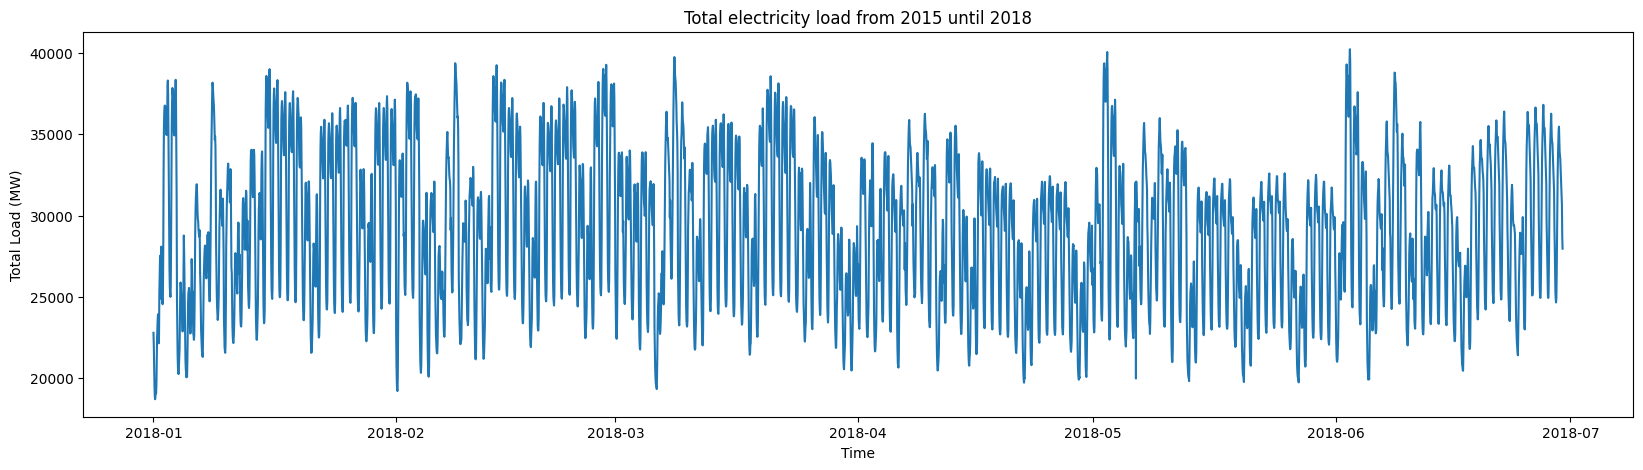

In [13]:
#Printing the timeseries to visualise it graphycally

fig, ax = plt.subplots(figsize = [20,5])

ax.plot(df.loc['2018-01-01 00:00:00':'2018-06-30 00:00:00'].index, df.loc['2018-01-01 00:00:00':'2018-06-30 00:00:00']['total load actual'])
plt.title('Total electricity load from 2015 until 2018')
ax.set_xlabel('Time')
ax.set_ylabel('Total Load (MW)');

The graph fluctuates in inumerous peaks and troughs. It does not show any clear trend, apparently total load actual oscilates within a range. In order to visualise the patterns of total load actual better, the rolling average for a week, equivalent to 7 days, and approximatelly a month, equivalent to 30 days.

In [14]:
#Adding rolling averages to our dataset
#Adding weekly rolling average window = 7*24 = 168
df['1weekaverage'] = df['total load actual'].rolling(window = 168).mean()
#Adding monthly rolling average window = 24*30 = 720 
df['30daysaverage'] = df['total load actual'].rolling(window = 720).mean()

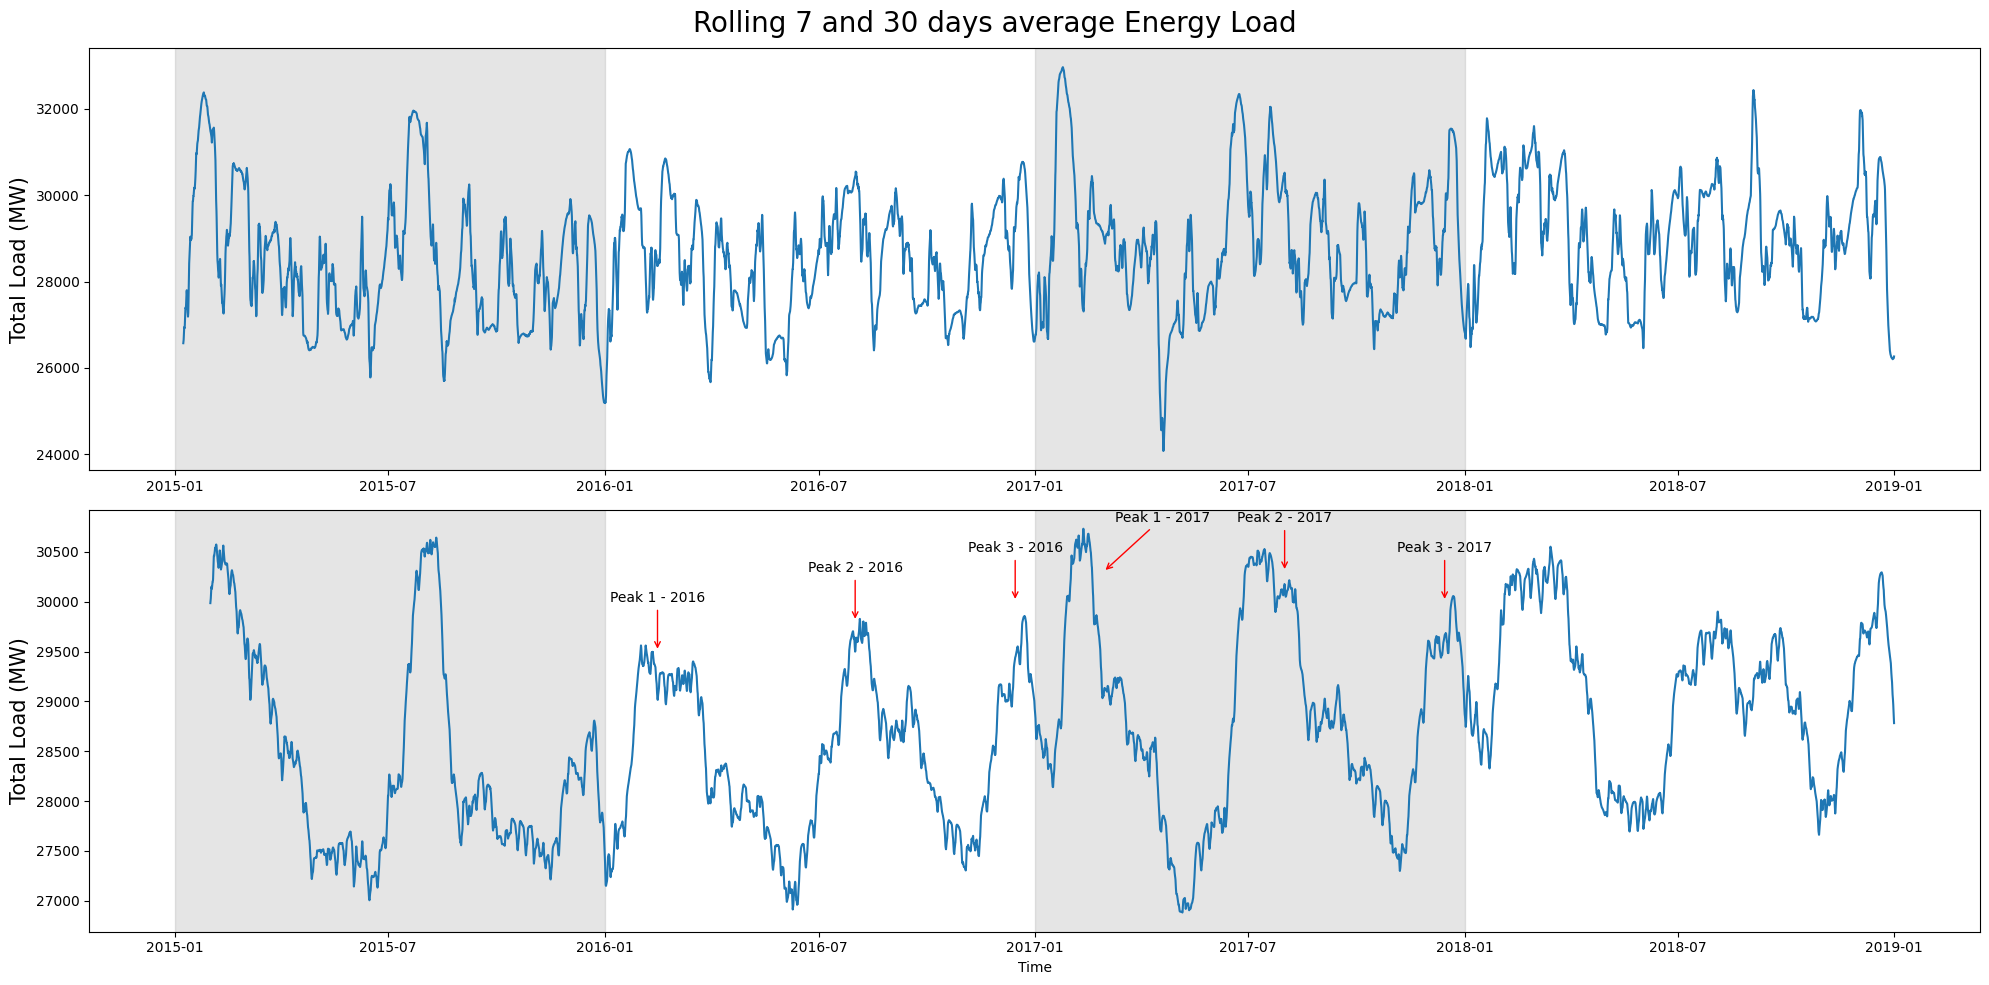

In [15]:
#Printing the timeseries to visualise it graphycally

fig, ax = plt.subplots(2,1, figsize = [20,10])

ax[0].plot(df.index, df['1weekaverage'])
ax[0].set_ylabel('Total Load (MW)', fontsize = 15);
ax[0].axvspan('2015-01-01 00:00:00', '2015-12-31 23:00:00', color='#808080', alpha=0.2)
ax[0].axvspan('2017-01-01 00:00:00', '2017-12-31 23:00:00', color='#808080', alpha=0.2)
ax[1].plot(df.index, df['30daysaverage'])
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Total Load (MW)', fontsize = 15);
ax[1].axvspan('2015-01-01 00:00:00', '2015-12-31 23:00:00', color='#808080', alpha=0.2)
ax[1].axvspan('2017-01-01 00:00:00', '2017-12-31 23:00:00', color='#808080', alpha=0.2)

peaks = [
    (pd.Timestamp('2016-02-15 00:00:00'), 29500, 'Peak 1 - 2016'),
    (pd.Timestamp('2016-08-01 00:00:00'), 29800, 'Peak 2 - 2016'),
    (pd.Timestamp('2016-12-15 00:00:00'), 30000, 'Peak 3 - 2016'),
    (pd.Timestamp('2017-02-28 00:00:00'), 30500, 'Peak 1 - 2017'),
    (pd.Timestamp('2017-08-01 00:00:00'), 30300, 'Peak 2 - 2017'),
    (pd.Timestamp('2017-12-15 00:00:00'), 30000, 'Peak 3 - 2017'),
]
for xx, yy, txt in peaks:
    if xx == pd.Timestamp('2017-02-28 00:00:00'):
        xy = xx + pd.Timedelta(hours = 1200)
        yy = yy-200
    else: xy = xx
    ax[1].annotate(
        txt,
        xy=(xx, yy),              # x from index, y from value
        xytext=(xy, yy + 500),     # where the text goes
        arrowprops=dict(arrowstyle="->", color="red"),
        fontsize=10,
        ha="center"
    )


fig.suptitle('Rolling 7 and 30 days average Energy Load', fontsize = 20, y=0.98)
plt.tight_layout()
plt.savefig('Rolling 7 and 30 days average Energy Load.png', dpi=200, bbox_inches = 'tight')
plt.show()

A 7 days rolling average does not help much in finding patterns within the data. However, a 30 days rolling average unveils patterns that helps to understand the data. The 4 years of data present 2 clear peaks per year and troughs per year, representing months of higher and lower electricity demand. One peak happens between the end and the beginning of the year. 

The consume start raising from november and reaches a local maximum and the descents to get to a local minimum on the beginning of January. In the sequence, the energy load increases again to reach a peak in around February, and it will descend again to a lower consume around May and June. 

Some years shows a shaper increase held for short time, whereas in other the energy consume increases and it reaches a steady plateau that lasts for a couple of months. It is clear that there is an anual seasonality within the data, what was actually expected.

A plot of 2 shorter windows of the load will be print now, so that it is possible to view the data zoomed in. The windows will be 1 week and 1 month.

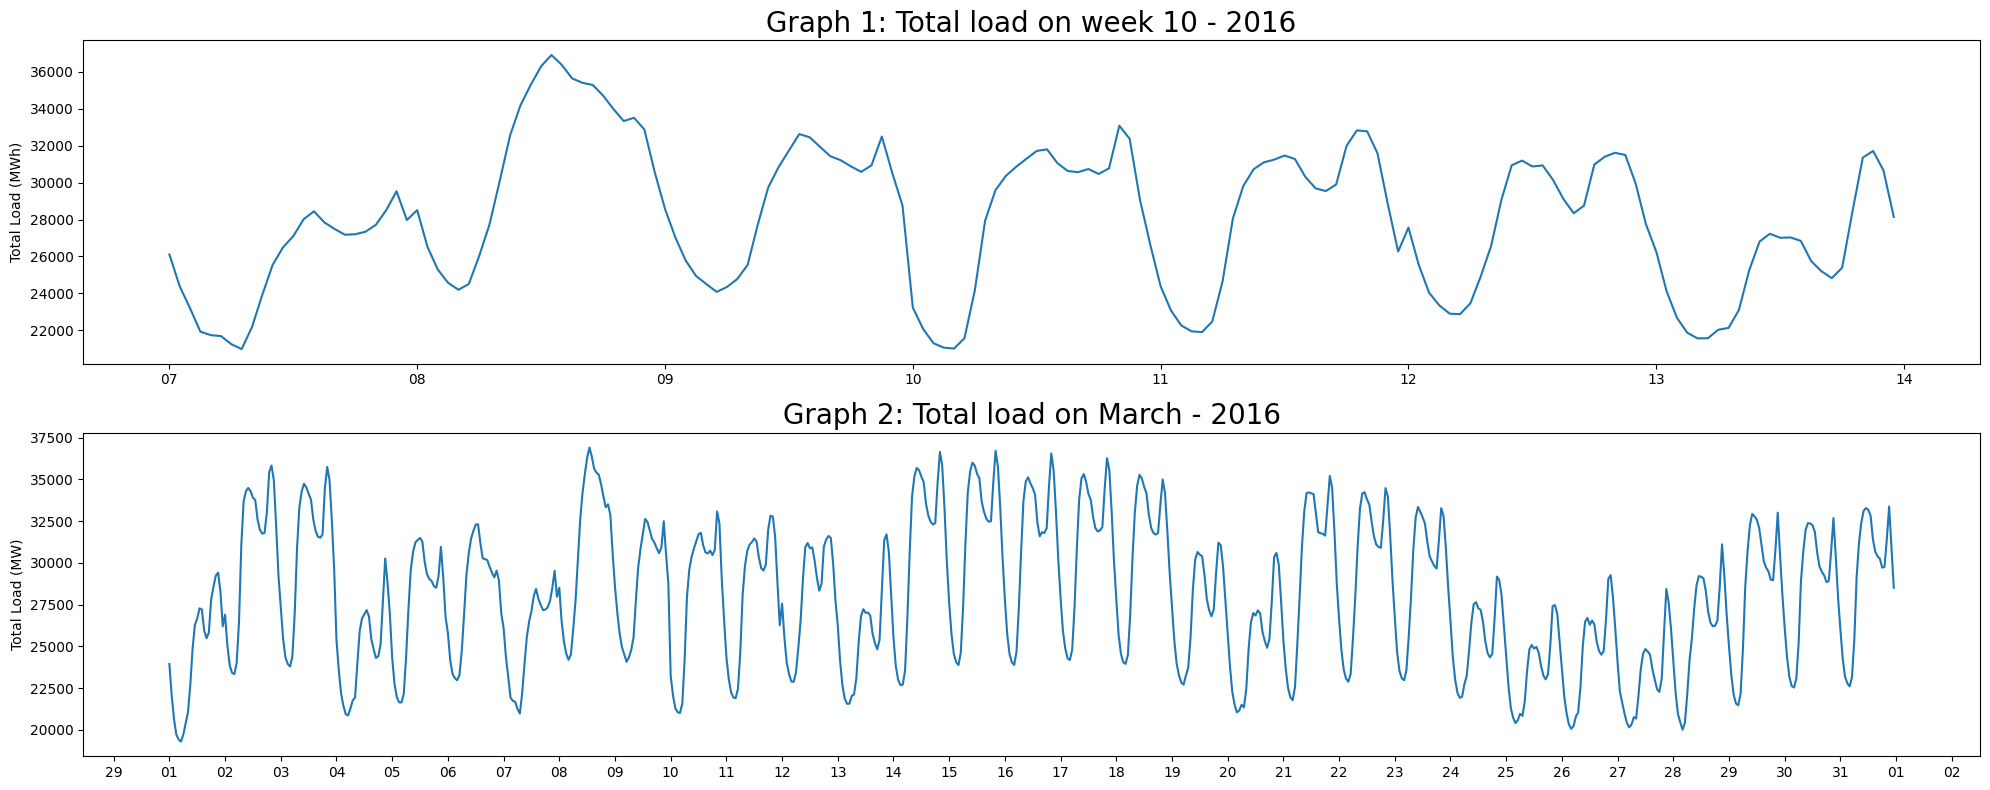

In [16]:
#Ploting 2 different zooms of data focusing in March-2016.
fig, ax = plt.subplots(2,1, figsize = [20,8])

ax[0].plot(df[df['year'] == 2016][df['woy'] == 10].index, 
           df[df['year'] == 2016][df['woy'] == 10]['total load actual'])
ax[0].set_title('Graph 1: Total load on week 10 - 2016', fontsize = 20)
ax[0].set_ylabel('Total Load (MWh)')
ax[0].xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%d"))
ax[1].plot(df[df['year'] == 2016][df['month'] == 3].index, 
           df[df['year'] == 2016][df['month'] == 3]['total load actual'])
ax[1].set_title('Graph 2: Total load on March - 2016', fontsize = 20)
ax[1].set_ylabel('Total Load (MW)');
ax[1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%d"))
fig.tight_layout()
fig.show()

Is it possible to observe from Graph 1 that the data seems to repeat a similar patterm every day, 2 peaks separated by a little dip. In some days the peaks and troughs are sharper, whereas in other they are more sutle. 

From Graph 2, a pattern is very clear between the day 14 and 21, 5 days of higher consume followed by two days of lower consumer, each one of these days showing the same patterns of Graph 1. This patterns repeats in the previous and following weeks of this mentioned, however less clearly.

This information combined indicate daily and weekly seasonality, which will be confirmed with data aggregation.

## 2.2. Analysing seasonalities

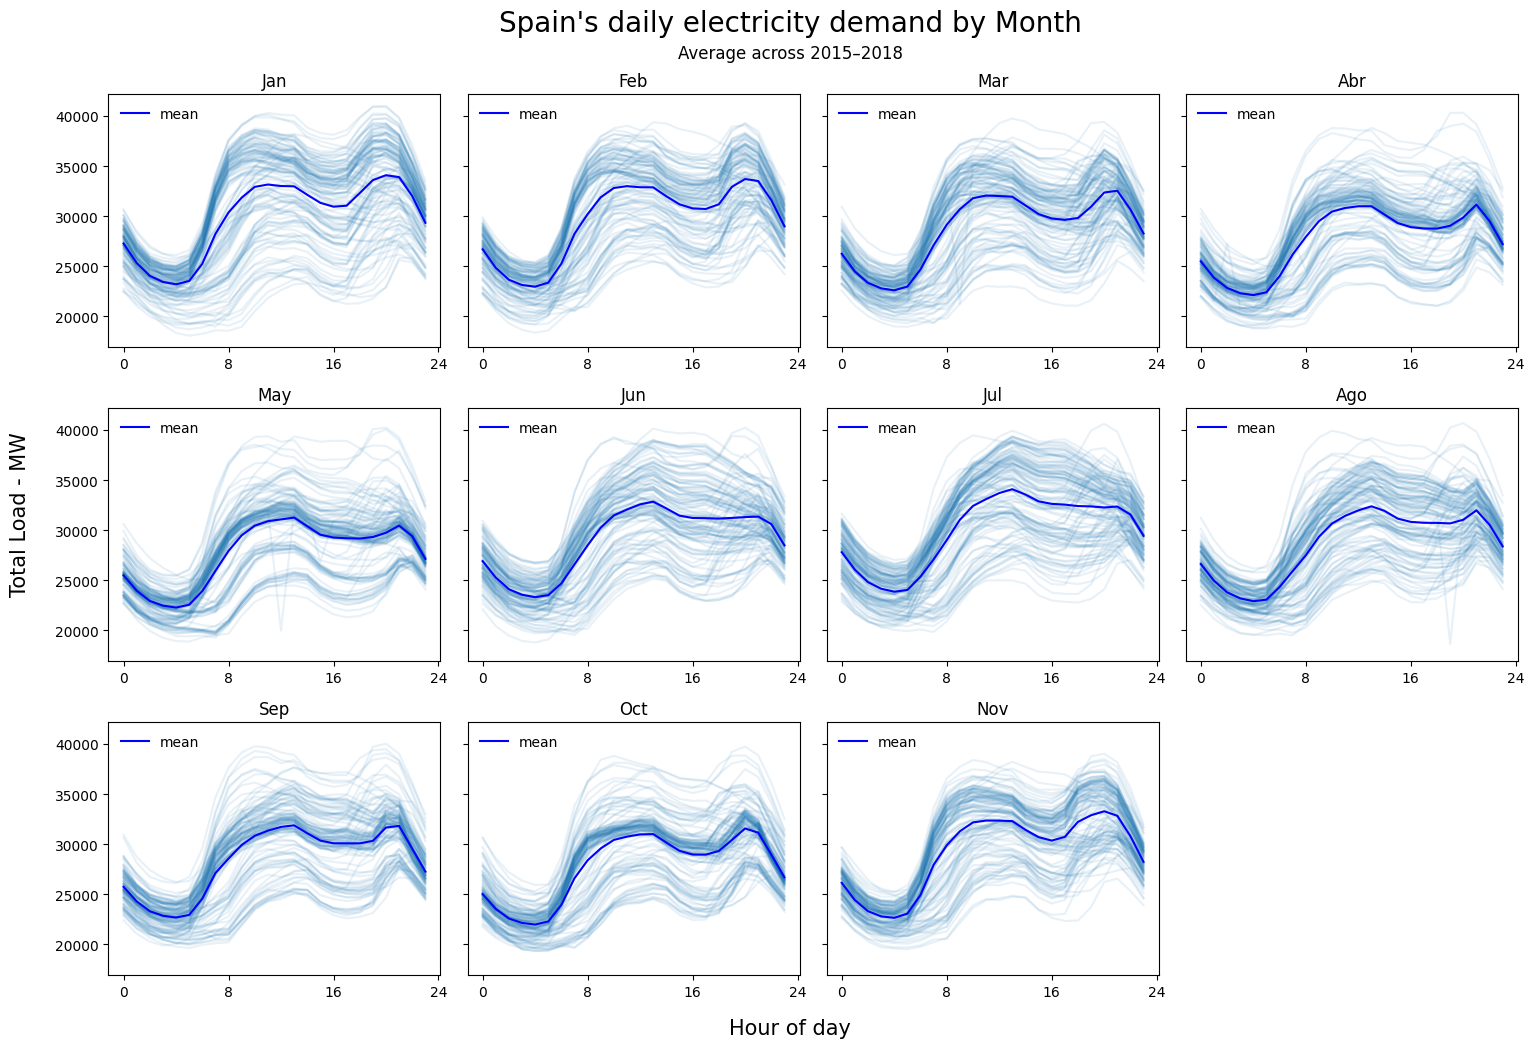

In [38]:
##https://towardsdatascience.com/multi-seasonal-time-series-decomposition-using-mstl-in-python-136630e67530
#Plotting daily behavior averaged by hour in each month of our data.

fig, ax = plt.subplots(nrows=3, ncols=4, figsize=[15, 10], sharey=True)
fig.subplots_adjust(top=0.75)
ax = ax.flatten()
sns_blue = sns.color_palette(as_cmap=True)[0]
MONTHS = ['Jan','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dec']

for ix, month in enumerate(MONTHS):

    # Plot individual ts
    daily_ts = []
    for _, ts in (
        df[['total load actual', 'dom', 'month', 'year']]
        .query(f'month == {ix+1}')
        .groupby(by = ['dom', 'year'])
    ):
        daily_ts.append(ts.reset_index()['total load actual'])
        ts.reset_index()['total load actual'].plot(
            alpha=0.1, ax=ax[ix], color=sns_blue, label='_no_legend_'
        )
        ax[ix].set_xticks(np.arange(0, len(ts) + 1, 8))
        ax[ix].set_title(month)

    # Plot the mean ts
    pd.concat(daily_ts, axis=1).mean(axis=1).plot(
        ax=ax[ix], color='blue', label='mean', legend=True
    )
    ax[ix].legend(loc='upper left', frameon=False)

fig.text(0.5, -0.02, 'Hour of day', ha='center', fontsize = 15)
fig.text(-0.02, 0.5, 'Total Load - MW', va='center', rotation='vertical', fontsize = 15)
fig.suptitle("Spain's daily electricity demand by Month", fontsize = 20, y = 1.005)
fig.text(0.5, 0.97, "Average across 2015–2018", fontsize=12, 
         ha='center', va='top')
fig.delaxes(ax[-1])
fig.tight_layout()
plt.savefig("Spain's daily electricity demand by Month", dpi=200, bbox_inches = 'tight')
fig.show()

Each month present different a slightly different daily pattern, however, within each month there is a clear repetition of the daily pattern. Furthermore, we can see a gradual transition from the beginning of the year to the middle of the year, in which two daily peaks become more round, reaching something similar to a plateau through the day. The trough gets deeper towards the end of the year, returning to its original shape on the beginning of next year. 

It is also observable that each month has days with characteristics similar to the previous and subsequent month, confirming the gradual transition of the patterns. This graph confirms both the presence of Daily seasonality and yearly seasonality.

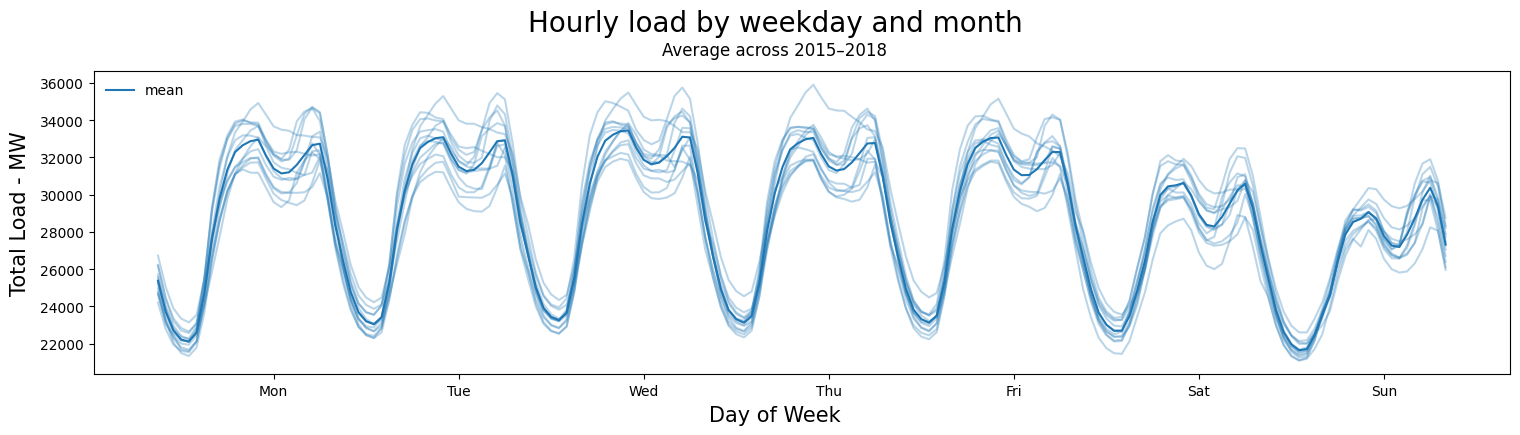

In [56]:
##Plotting overlapping months for weekly demand of energy
dow = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
fig, ax = plt.subplots(figsize=[15, 4])
sns_blue = sns.color_palette(as_cmap=True)[0]

for ix, month in enumerate(MONTHS):
    (
        df.groupby(by=['month','dow','hour'])['total load actual']
        .mean()[ix+1]
        .plot(alpha = 0.3, ax=ax, color = sns_blue, label='_no_legend_')
    )

df.groupby(by=['dow','hour'])['total load actual'].mean().plot(ax = ax, label = 'mean')
plt.xticks(ticks=np.arange(15, 182, 24), labels=dow)
ax.set_xlabel('')
ax.legend(loc='upper left', frameon=False)

fig.text(0.5, -0.02, 'Day of Week', ha='center', fontsize = 15)
fig.text(-0.01, 0.5, 'Total Load - MW', va='center', rotation='vertical', fontsize = 15)
fig.suptitle("Hourly load by weekday and month", fontsize = 20, y=1.01)
fig.text(0.5, 0.93, "Average across 2015–2018", fontsize=12, 
         ha='center', va='top')
fig.tight_layout()
plt.savefig("Hourly load by weekday and month", dpi=200, bbox_inches = 'tight')
fig.show()

There is a clear weekly seasonality when the data is visualised through the months, averaging the hourly consumption by weekday. From Monday until Friday, there is little difference in consume within a same month, whereas Saturday and Sundays present a clear drop in the consume. It is also observable that July have an extreme behaviour mostly similar to a single peak during the day, while January has an extreme behaviour mostly containing two peaks and a deep trough between them every day. The other months show a gradual transition between them. 

This graph shows weekly seasonality. It also indicates that adding a feature of yearly season might be benefical to the analysis. 

Another features that might be benefical are a feature to identify weekends, and holidays. Being the most important holiday in west Christmas, as well as the fact the forecasting horizon goes through Christmas, features will be added to identify the Christmas season, and the end of the year.

In [19]:
#Verifying the mean of the different days of the week

df.groupby('dow')['total load actual'].mean()

dow
0    29046.537480
1    29451.107171
2    29745.850761
3    29451.413278
4    29350.653808
5    27488.984948
6    26364.172548
Name: total load actual, dtype: float64

In [20]:
#Verifying the difference between weekdays and weekends

df.groupby('is_weekend')['total load actual'].mean()

is_weekend
False    29408.749381
True     26926.578748
Name: total load actual, dtype: float64

The numbers show a substantial difference between Weekends and Weekdays.

In [21]:
#Creating a list with the seasons
seasons = ['Winter', 'Spring', 'Summer', 'Autumn']

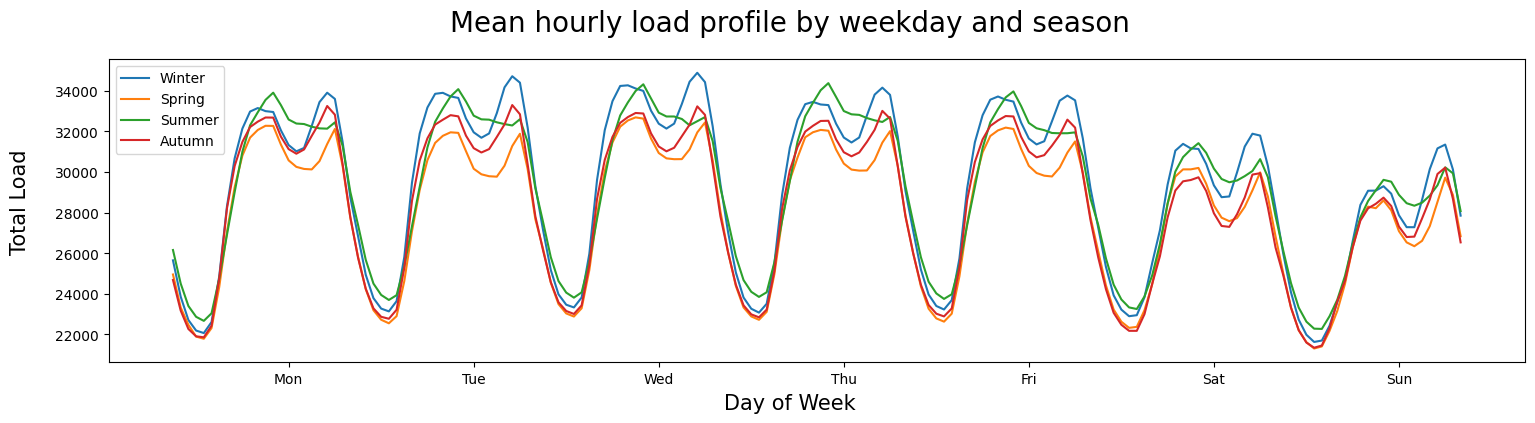

In [22]:
#Plotting overlapping seasons for weekly demand of energy
fig, ax = plt.subplots(figsize=[15, 4])
for ix, season in enumerate(seasons):
    df.groupby(by=['season','dow','hour'])['total load actual'].mean()[season].plot(legend = True, 
                                                                                     label = season,
                                                                                     alpha = 1)
plt.xticks(ticks=np.arange(15, 182, 24), labels=dow)
ax.set_xlabel('')
fig.text(0.5, -0.02, 'Day of Week', ha='center', fontsize = 15)
fig.text(-0.02, 0.5, 'Total Load', va='center', rotation='vertical', fontsize = 15)
fig.suptitle('Mean hourly load profile by weekday and season', fontsize = 20)
fig.tight_layout()
fig.show()

In [23]:
#Verifying the mean of Load by season

df.groupby('season')['total load actual'].mean().sort_values()

season
Spring    27964.597430
Autumn    28369.008127
Summer    29164.091486
Winter    29304.595683
Name: total load actual, dtype: float64

Demand of energy has different profiles based on the seasons of the year, in which summer is one extreme, showing mostly one clear peak of demand per day, and winter is another extreme, with a second peak of demand per day even higher than the first. 

Lastly, it is important to verify seasonality within the months. Are there patterns repeating every month? To visualise it, it will be plotted a Hourly energy demand averaged by day and month.

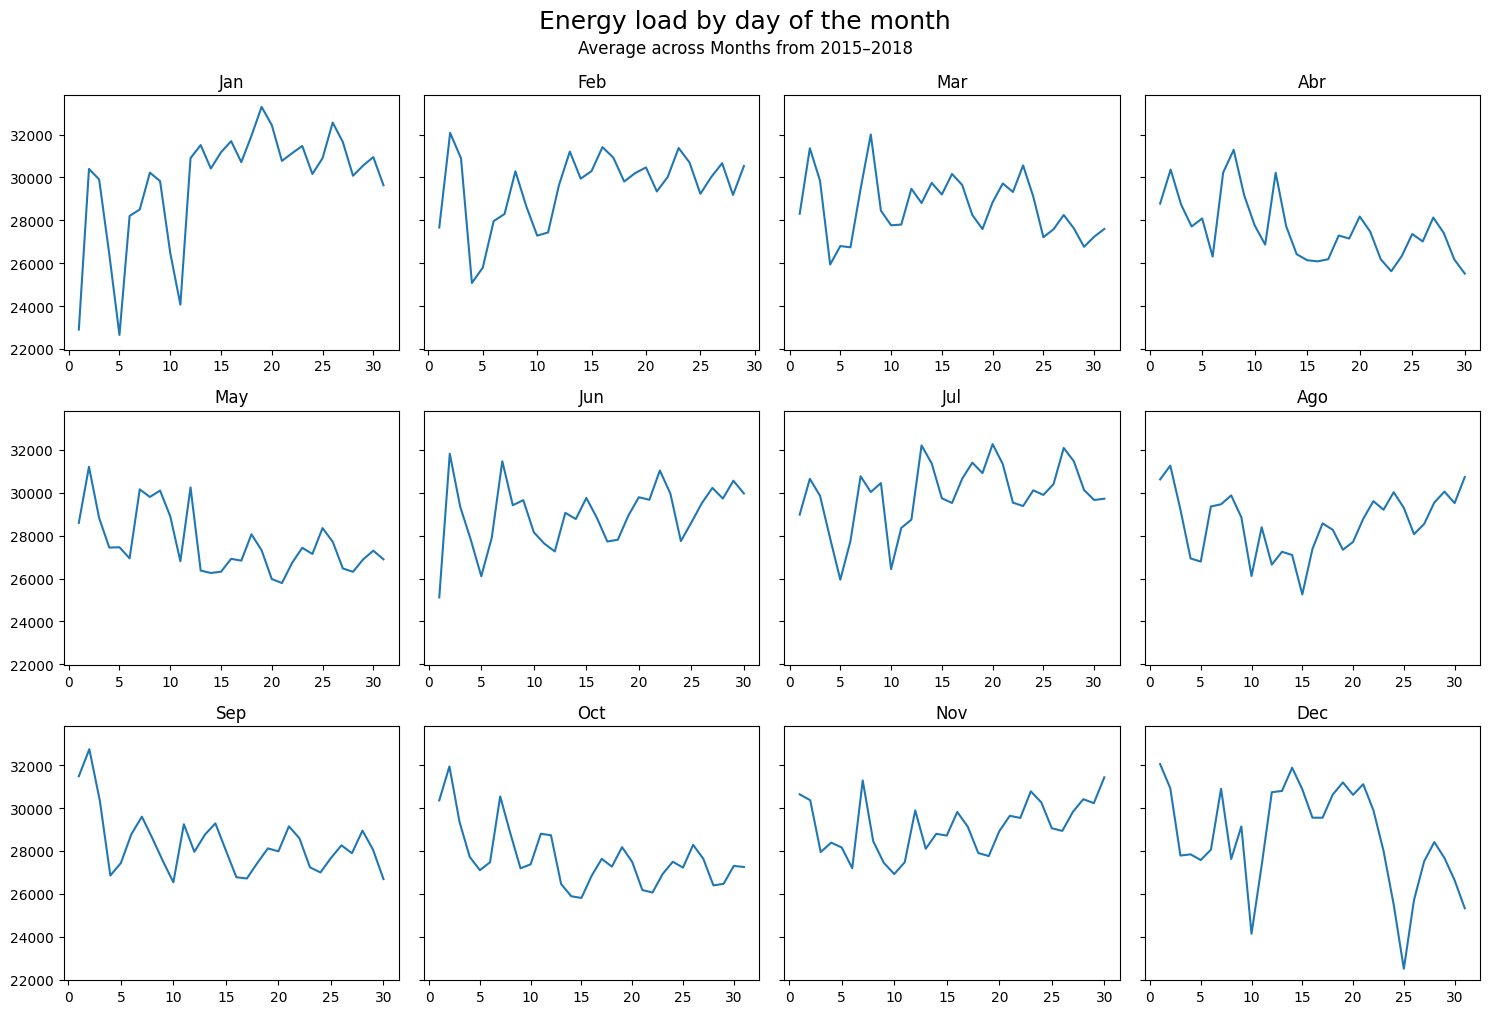

In [51]:
#Plotting monhtly behavior averaged by day in each month of our data.

fig, ax = plt.subplots(nrows=3, ncols=4, figsize=[15, 10], sharey=True)
ax = ax.flatten()
for ix, month in enumerate(MONTHS):
    df.groupby(by=['month', 'dom'])['total load actual'].mean()[ix+1].plot(ax = ax[ix])
    ax[ix].set_title(month)
    ax[ix].set_xlabel('')

fig.suptitle("Energy load by day of the month", fontsize = 18, y=1.01)
fig.text(0.5, 0.98, "Average across Months from 2015–2018", fontsize=12, 
         ha='center', va='top')
fig.tight_layout()
plt.savefig("Energy load by day of the month", dpi = 200, bbox_inches = 'tight')
fig.show()

The days of the month do not show any repetitive pattern that could indicate seasonality. Some month show a similar shape in many peaks and troughs, but it is rather because of the weekly seasonality than something new. 

Therefore, throgh the analysis 3 seasonalities were found within the data.
<br>1- Daily Seasonality - 24 hours
<br>2- Weekly Seasonality - 168 hours
<br>3- Yearly Seasonality - 8760 hours

In [25]:
#Verifying total load grouped by dom to verify if there is any day of the month with clear peaks

df.groupby('dom')['total load actual'].mean().sort_values()

dom
5     26659.215712
10    26992.092014
4     27167.652778
11    27517.637587
6     27725.067708
25    28111.726562
31    28167.944940
30    28383.513258
15    28444.612847
24    28467.077257
29    28553.306019
26    28674.913628
17    28692.108507
16    28750.790365
1     28794.276042
28    28795.738281
14    28825.026042
18    28842.315972
9     28875.539497
22    28974.019965
23    28999.184462
19    29002.342014
13    29023.852431
27    29076.102431
21    29082.497396
12    29206.773438
20    29225.951389
3     29338.388889
8     29704.767361
7     30060.412326
2     31264.911024
Name: total load actual, dtype: float64

In [26]:
#Getting descriptive analysis of the previous group 

df.groupby('dom')['total load actual'].mean().describe()

count       31.000000
mean     28690.314779
std        889.989034
min      26659.215712
25%      28414.063052
50%      28795.738281
75%      29049.977431
max      31264.911024
Name: total load actual, dtype: float64

The Standard Deviation of the mean of load per day is very low compared to the mean, the variable does not show seasonality.

In [27]:
#Group data by the engineered features 'is_holiday' to evaluate the different levels

df.groupby('is_holiday')['total load actual'].mean()

is_holiday
0    28759.289652
1    26743.683712
Name: total load actual, dtype: float64

Although there is signficant difference, it is interesting to verify that the gap might be more pronounced when separating the weekends.

In [28]:
#Grouping data by the features 'is holiday' and 'is weekend'

df.groupby(['is_holiday', 'is_weekend'])['total load actual'].mean()

is_holiday  is_weekend
0           False         29496.787177
            True          26947.923780
1           False         26946.136574
            True          25832.645833
Name: total load actual, dtype: float64

Now it is possibe to verify a very signifcant gap between regular working days, and holidays, both that fall on weekend and not.

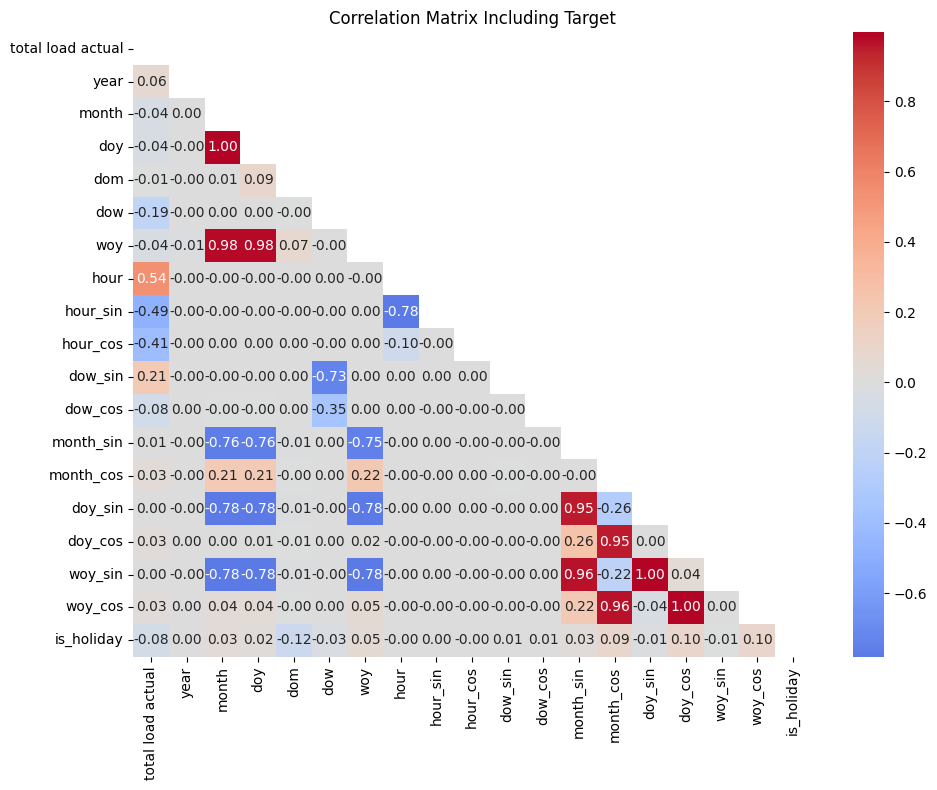

In [29]:
# Verifying correlation amongst the features studyied
numeric_df = df.select_dtypes(include=[np.number]).drop(columns = ['total load forecast', '1weekaverage', '30daysaverage'])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix Including Target')
plt.tight_layout()
plt.show()


The features engineered play an important role in understanding the data. Although there are feature with 100% correlation, tests have shown that keeping both of them sometimes lead to better models, they will be kept for now, and tests will be carried forward on the next section to decide which features should stay.